## Deep Learining & Art: Neural Style Transfer 🖼
Here we leran about Neural Style Transfer, the algorithm was created by [Gatys et al. (2015)](https://arxiv.org/abs/1508.06576).


Here we implement
* **Neural Style Transfer algorithm**
* **Generate  novel artistic images using the algorithm**

Most of the algorithm we studied optimized the cost function to get a set of parameter values. In Neural Style Transfer we'll optimize a cost function to get pixel values.



In [2]:
from google.colab import files
files.upload()


MessageError: CustomError: Timed out waiting for output iframe load.

In [ ]:
!unzip Art_images.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
import os

# -----------------------------
# Image utilities
# -----------------------------
def load_and_process_image(path, max_dim=512):
    img = Image.open(path).convert("RGB")
    scale = max_dim / max(img.size)
    img = img.resize((int(img.size[0] * scale), int(img.size[1] * scale)))
    img = np.array(img).astype(np.float32)
    img = tf.expand_dims(img, axis=0)
    return tf.keras.applications.vgg19.preprocess_input(img)

def deprocess_image(img):
    img = img.numpy().squeeze()
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]
    img = np.clip(img, 0, 255).astype("uint8")
    return img

# -----------------------------
# VGG model
# -----------------------------
def get_vgg_model(content_layers, style_layers):
    vgg = tf.keras.applications.VGG19(
        include_top=False, weights="imagenet"
    )
    vgg.trainable = False

    outputs = (
        [vgg.get_layer(name).output for name in style_layers] +
        [vgg.get_layer(name).output for name in content_layers]
    )

    return tf.keras.Model(vgg.input, outputs)

# -----------------------------
# Loss functions
# -----------------------------
def gram_matrix(tensor):
    result = tf.linalg.einsum("bijc,bijd->bcd", tensor, tensor)
    h, w = tensor.shape[1], tensor.shape[2]
    return result / tf.cast(h * w, tf.float32)

def style_loss(style_outputs, gen_outputs):
    loss = 0
    for s, g in zip(style_outputs, gen_outputs):
        loss += tf.reduce_mean(tf.square(gram_matrix(s) - gram_matrix(g)))
    return loss / len(style_outputs)

def content_loss(content_output, gen_output):
    return tf.reduce_mean(tf.square(gen_output - content_output))

# -----------------------------
# Training step
# -----------------------------
@tf.function
def train_step(image, extractor, style_targets, content_target,
               style_weight, content_weight, optimizer):

    with tf.GradientTape() as tape:
        outputs = extractor(image)
        style_outputs = outputs[:len(style_targets)]
        content_output = outputs[len(style_targets):][0]

        s_loss = style_loss(style_targets, style_outputs)
        c_loss = content_loss(content_target, content_output)
        total_loss = style_weight * s_loss + content_weight * c_loss

    grad = tape.gradient(total_loss, image)
    optimizer.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, -128.0, 128.0))
    return total_loss

# -----------------------------
# Main NST pipeline
# -----------------------------
def neural_style_transfer(
    content_path,
    style_path,
    epochs=300,
    style_weight=1e-2,
    content_weight=1e4
):
    content_layers = ["block5_conv2"]
    style_layers = [
        "block1_conv1",
        "block2_conv1",
        "block3_conv1",
        "block4_conv1",
        "block5_conv1",
    ]

    extractor = get_vgg_model(content_layers, style_layers)

    content_img = load_and_process_image(content_path)
    style_img = load_and_process_image(style_path)

    style_targets = extractor(style_img)[:len(style_layers)]
    content_target = extractor(content_img)[len(style_layers):][0]

    generated_img = tf.Variable(content_img)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)

    print("Starting style transfer...")
    start = time.time()

    for i in range(epochs):
        loss = train_step(
            generated_img,
            extractor,
            style_targets,
            content_target,
            style_weight,
            content_weight,
            optimizer
        )

        if i % 50 == 0:
            print(f"Step {i}, Loss: {loss.numpy():.2f}")

    print(f"Done in {time.time() - start:.2f} seconds")

    final_img = deprocess_image(generated_img)
    return final_img

# -----------------------------
# Run
# -----------------------------
if __name__ == "__main__":
    content_image_path = "content.jpg"
    style_image_path = "style.jpg"

    output = neural_style_transfer(
        content_image_path,
        style_image_path,
        epochs=300
    )

    plt.imshow(output)
    plt.axis("off")
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'content.jpg'

In [ ]:
print(tf.__version__)


2.19.0


## Problem Statement

Neural Style Transfer (NST) is one of the most fun techniques in deep learning. As seen below, it merges two images, namely, a "content" image (C) and a "style" image (S), to create a "generated" image (G). The generated image G combines the "content" of the image C with the "style" of image S.

Here we're going to generate an image of the Louvre museum in Paris(content image C),mixed with a painting by Claude Monet, a leader of the impressionist movement (style image C).


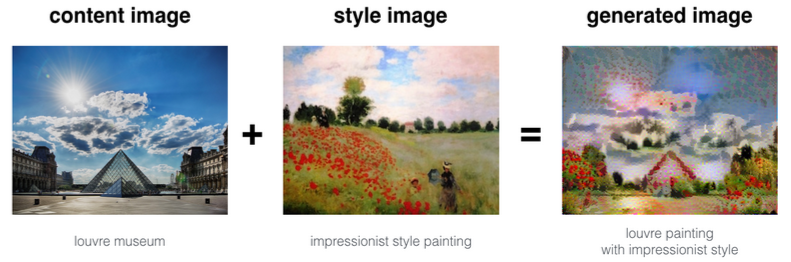

Let see how can we do that...

## Transfer Learning
Neural Style Transfer (NST) uses a previously trained convolutional network, and builds on top of that. The idea of using a network trained on a different task and applying it to a new task is called transfer learning.

Following the original [NST paper] (https://arxiv.org/abs/1508.06576), we will use the VGG network. Specifically, we'll use VGG-19, a 19-layer version of the VGG network. This model has already been trained on the very large ImageNet database, and thus has learned to recognize a variety of low level features (at the earlier layers) and high level features (at the deeper layers).

In [ ]:
# Loading the parameters from VGG Model. This may take a few seconds
model = load_vgg_model("pretrained-model/imagenet-vgg-verydeep-19.mat")
print(model)

The model is stored in a python dict: where each variable name is the key and the corresponding value is a tensor that containing variable's value. To run an image through this network we have to feed the image to the model. In TF , we can do so using tf.assign function, we'll use the assign function as this


In [ ]:
model['input'].assign(image)

This assigns the image as an input to the model. After this, if you want to access the activations of a particular layer, say layer 4_2 when the network is run on this image, you would run a TensorFlow session on the correct tensor conv4_2, as follows:



In [ ]:
sess.run(model['conv4_2'])

## Neural Style Transfer
we'll build the NST algorithm in 3 steps:

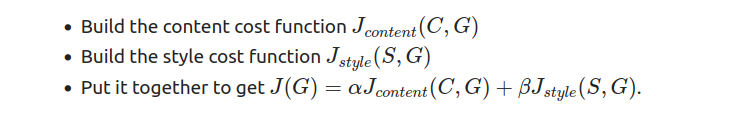

### Computing the content cost

IN our running example , the content image C will be the picture of the Louvre Museum in  Paris.Run the code below to see  a picture of the Louvre.


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Art_images/louvre.jpg")

plt.imshow(content_image)

The content image (C) shows the Louvre museum's pyramid surrounded by old Paris buildings, against a sunny sky with a few clouds.

** 3.1.1 - How do you ensure the generated image G matches the content of the image C?**

Here the earlier (shallower) layers of a ConvNet tend to detect lower-level features such as edges and simple textures, and the later (deeper) layers tend to detect higher-level features such as more complex textures as well as object classes.


We would like the "generated" image G to have similar content as the input image C. Suppose you have chosen some layer's activations to represent the content of an image. In practice, you'll get the most visually pleasing results if you choose a layer in the middle of the network--neither too shallow nor too deep. (After we have finished this exercise, we can come back and experiment with using different layers, to see how the results vary.)

So, suppose you have picked one particular hidden layer to use. Now, set the image C as the input to the pretrained VGG network, and run forward propagation. Let $$a^(C)$$ be the hidden layer activations in the layer we had chosen. This will be an $$n_H x n_W x n_X$$ tensor. Repeating the process with the image G: Set the G as the input, and run forward  propagation Let $$a^(G)$$ be the corresponding hidden layer activation. We'll define as the content cost function as:

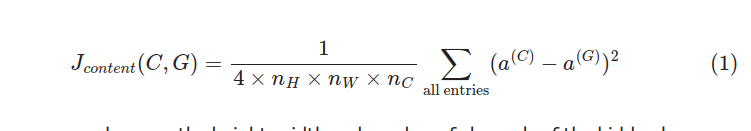


Here the $$n_H, n_W ,  and\ n_C $$ are the height , wifth and number of channels of the hidden layer we chosen and appear in a normalization term in the cost. For clarity note that $$a^(C)$$ and $$a^(G)$$ are the volumes corresponding to a hidden layer's activation. In order to compute the cost $$J_content(C, G)$$ it might also be convenientto unroll these D volumes to a 3D matrix, as shown below. . (Technically this unrolling step isn't needed to compute  $$J_content$$
, but it will be good practice for when you do need to carry out a similar operation later for computing the style const $$J_style$$
.)

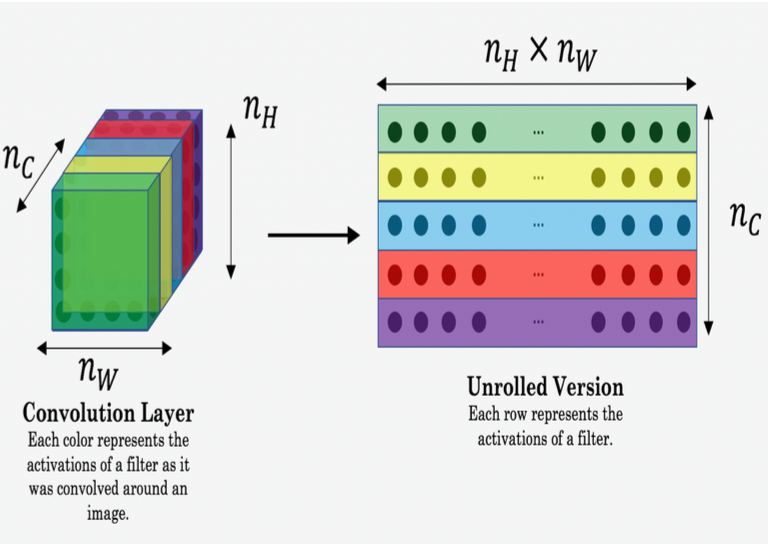

Computing the "content cost"" using the TensorFlow

**The 3 steps**


In [ ]:
def compute_content_cost(a_C, a_G):

  """ Computes the content cost

  Arguements:
    a_C -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing content of the image C
    a_G -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing content of the image G

  Returns --
    J_content -- scalar that we compute using the equation 1 above.

  """

  m, n_H, n_W, n_C = a_G.get_shape().as_list()

  a_C_unrollled = tf.transpose(a_C)
  aG_untolled = tf.transpose(a_G)

  J_content = (1/ (4* n_H * n_W * n_C)) * tf.reduce_sum(tf.pow((a_G_unrolled - a_C_unrolled), 2))

  return J_content



In [ ]:

tf.reset_default_graph()

with tf.Session() as test:

  tf.test_random_seed(1)
  a_C = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)
  a_G = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)
  J_content = compute_content_cost(a_C, a_G)
  print("J_content = " + str(J_content.eval()))

#### Notes
**The content cost takes a hidden layer actication of the neural network , and measures how different $$a_C$$ and $$a_G$$ are. When we minimize the content cost later , this will help make sure the G has similar content as C.**


## Computing the Stle Cost

For our running egL we will use the following style image



In [ ]:
style_image = Image.open("Art_images/monet_800600.jpg")

plt.imshow(style_image)

#### Let see how can we define a "style" const function $$J_style(S, G)$$



## Style Matrix
The style matrix is also calle d"Gram Matrix".In linear algebra , the Gram matric G of a set of vectors (v1, ..., vn) is the matrix of dot products, whose entires are $$G_ij = v_i^T v_j = np.dot(v_i, v_j)$$.In other words $$G_ij$$ compares how similar the $$v_i$$ is to $$v_j$$; if they are highly similar we expect them to have a large dot procuct , and thus for $$G_ij$$ to be large.


Note that there is an unfortunate collision in the variable names used here. We are following common terminology used in the literature, but $$G$$ is used to denote the Style matrix (or Gram matrix) as well as to denote the generated image $$G$$ . We will try to make sure which $$G$$  we are referring to is always clear from the context.

In NST we can compute the Style matirx by multilpyingthe "unrolled" filter matirx with their transpose.



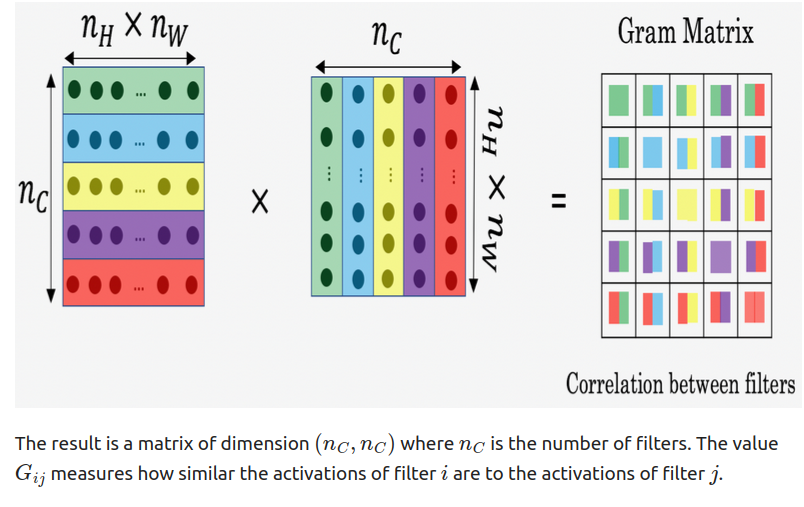

One important part of the gram matrix is that the diagonal elements such as $$G_ij$$ also measures how active filter i is . FOr eg: suppose filter i is detecting vertical textures in the imag. Then the $$G_ii$$ measures how common vertical textures are in the image as a whole. If $$G_ii$$ is larage this means that the image has a lot of vertical textures.

By capturing the prevelance of different types of features ($$G_ij$$) as well as how much different features occur together $$G_ij$$ the Style matrix $$G$$ measures the style of an image.



Here We : Using TensorFlow, implement a function that computes the Gram matrix of a matrix A. The formula is: The gram matrix of A is $$G_A = AA^T$$



In [ ]:
def gram_matrix(A):
  GA = tf.matmul(A, tf.transpose(A))

  return GA


In [ ]:
import tensorflow as tf

tf.random.set_seed(1)

A = tf.random.normal([3, 2*1], mean=1, stddev=4)
GA = gram_matrix(A)

print("GA =", GA.numpy())


### Style Cost

After generating the Style matrix (Gram matrix), our goal will be to minimize the distance between the Gram matrix of the "style" image S and that of the "generated" image G. For now, we are using only a single hidden layer $$a^[l]$$ and the corresponding style cost for the layer is defiend as:
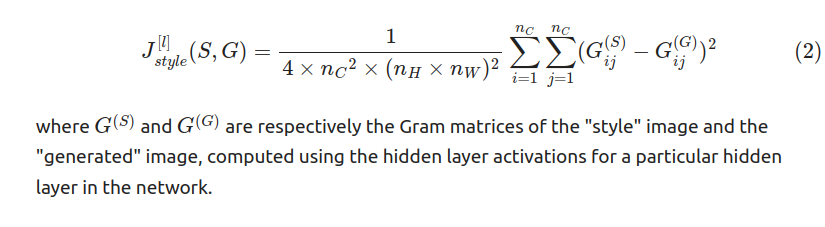


To compute the style cost for a single layer.

WE follow these 3 steps to implement this fn:
1. Retrieve dimensions from the hidden layer activations a_G:
  * To retrieve dimensions from a tensor of X, use `X.get_shape().as_list()`
2. unroll the hidden  layer activations  a_S and a_G into a 2D matrices.
3. Compute the style matirx of the images S and G.
4. Compute the style cost.


In [ ]:
def comute_layer_style_cost(a_S, a_G):
  """
  Arguments:
    a_S -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing style of the image S
    a_G -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing style of the image G

  Returns:
  J_style_layer  -- tensor   representing a scalar value, style cost defined above by equation (2)
  """
  m, n_H, n_W, n_C = a_G.get_shape().as_list()

  a_S = tf.transpose(tf.reshape(a_S, [n_H*n_W, n_C]))
  a_G = tf.transpose(tf.reshape(a_G, [n_H*n_W, n_C]))

  GS  = gram_matrix(a_S)
  GG = gram_matrix(a_G)

  J_style_layer = (1./(4 * n_C**2 * (n_H*n_W)**2)) * tf.reduce_sum(tf.pow((GS - GG), 2))

  return J_style_layer








In [ ]:
tf.reset_default_graph()

tf.set_random_seed(1)
a_S = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)
a_G = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)

J_style_layer = compute_layer_style_cost(a_S, a_G)

print("J_style_layer = " + str(J_style_layer.eval()))

## Style Weights
So far you have captured the style from only one layer. We'll get better results if we "merge" style costs from several different layers. After completing this exercise, feel free to come back and experiment with different weights to see how it changes the generated image G . But for now, this is a pretty reasonable default:




In [ ]:
STYLE_LAYERS = [
    ('conv1_1', 0.2),
    ('onv2_1', 0.2),
    ('conv3_1', 0.2),
    ('conv4_1', 0.2),
    ('conv5_1', 0.2)
]

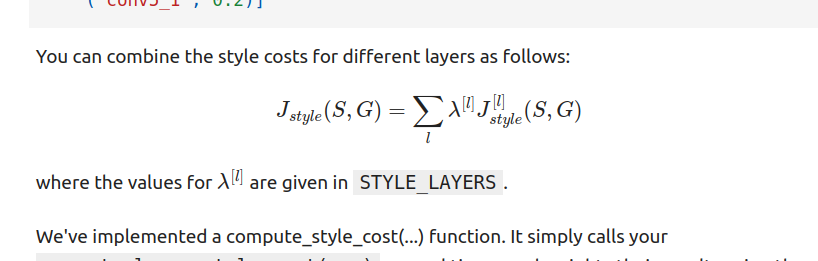



We implement a `compute_style_cost(...)` function. It simply calls your `compute_layer_style_cost(...)` several times, and weights their results using the values in STYLE_LAYERS.


In [ ]:
def compute_style_cost(model, style_features, STYLE_LAYERS):
    """
    Computes the overall style cost from several chosen layers

    Arguments:
    model -- dict or list containing generated image activations
    style_features -- dict containing style image activations
    STYLE_LAYERS -- list of tuples (layer_name, coefficient)

    Returns:
    J_style -- scalar tensor (style cost)
    """
    J_style = 0.0

    for layer_name, coeff in STYLE_LAYERS:
        a_S = style_features[layer_name]   # style image (constant)
        a_G = model[layer_name]             # generated image

        J_style_layer = compute_layer_style_cost(a_S, a_G)
        J_style += coeff * J_style_layer

    return J_style


Note: In the inner-loop of the for-loop above, `a_G` is a tensor and hasn't been evaluated yet. It will be evaluated and updated at each iteration when we run the TensorFlow graph in `model_nn()` below.

**Final _NOTE: The style of an image can be represented using the Gram matrix of a hidden layer's activations. However, we get even better results combining this representation from multiple different layers. This is in contrast to the content representation, where usually using just a single hidden layer is sufficient. - Minimizing the style cost will cause the image G to follow the style of the image S.**


## - Defining the total cost to optimize


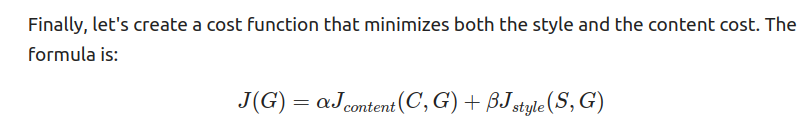

In [ ]:
def total_cost(J_content, J_style, alpha=10, beta= 40):
  J = alpha * J_content + beta  J_style

  return J

In [ ]:
tf.reset_default_graph()

np.random.seed(3)
J_content = np.random.randn()
J_style = np.random.randn()
J = total_cost(J_content, J_style)

print("J = " + str(J))


**Key takeaway:** The total cost is a linear combination of the content cost  
$J_{\text{content}}(C, G)$ and the style cost $J_{\text{style}}(S, G)$:

$$
J(G) = \alpha \, J_{\text{content}}(C, G) + \beta \, J_{\text{style}}(S, G),
$$

where $\alpha$ and $\beta$ are hyperparameters that control the relative weighting
between content and style.


## SOlving the Optimization Problem

Finally let's put all together to implement Neural Style Transfer!

Here's what the program will have to do:

    1.Create an Interactive Session
    2.Load the content image
    3.Load the style image
    4.Randomly initialize the image to be generated
    5.Load the VGG16 model
    6.Build the TensorFlow graph:
        * Run the content image through the VGG16 model and compute the content cost
        * Run the style image through the VGG16 model and compute the style cost
        * Compute the total cost
        * Define the optimizer and the learning rate
    7.Initialize the TensorFlow graph and run it for a large number of iterations, updating the generated image at every step.


Let go through the individual steps in detail.


You've previously implemented the overall cost J(G). We'll now set up TensorFlow to optimize this with respect to G. To do so, your program has to reset the graph and use an "Interactive Session". Unlike a regular session, the "Interactive Session" installs itself as the default session to build a graph. This allows you to run variables without constantly needing to refer to the session object, which simplifies the code.

Let start the interactive session


In [ ]:
import tensorflow as tf

A = tf.random.normal([3, 2], mean=1, stddev=4)
print(A)          # shows the tensor
print(A.numpy())  # shows actual values


In [ ]:
content_image = np.array(Image.open("Art_images/louvre_small.jpg"))
content_image = reshape_and_normalize_image(content_image)



Let's load, reshape and normalize our "style" image (Claude Monet's painting):


In [ ]:
style_image =  np.array(Image.open("Art_images/monet.jpg"))
style_image = reshape_and_normalize_image(style_image)



Now, we initialize the "generated" image as a noisy image created from the content_image. By initializing the pixels of the generated image to be mostly noise but still slightly correlated with the content image, this will help the content of the "generated" image more rapidly match the content of the "content" image.


In [ ]:
generated_image = generate_noise_image(content_image)
plt.imshow(generated_image[0])


Loading the VGG16 model


In [ ]:
model = load_vgg_model("pretrained-model/imagenet-vgg-verydeep-19.mat")

To get the program to compute the content cost, we will now assign `a_C and a_G` to be the appropriate hidden layer activations. We will use layer `conv4_2` to compute the content cost. The code below does the following:

1. Assign the content image to be the input to the VGG Model
2.  Set a_C to be the tensor giving the hidden layer activation for layer "conv4_2"
3. set the a_G to be tensor giving the hidden layer activation for the same layer
4. Compute the content cost using a_C and a_G.

In [ ]:
generated_iamge = tf.variable(generate_noise_image(content_image),
                              trainable=True)
CONTENT_LAYER = "block4_conv2"



In [ ]:
# Assign the content image to be the input of the VGG model.
# sess.run(model['input'].assign(content_image))

# Select the output tensor of layer conv4_2
# out = model['conv4_2']

# Set a_C to be the hidden layer activation from the layer we have selected
# a_C = sess.run(out)

# Set a_G to be the hidden layer activation from same layer. Here, a_G references model['conv4_2']
# and isn't evaluated yet. Later in the code, we'll assign the image G as the model input, so that
# when we run the session, this will be the activations drawn from the appropriate layer, with G as input.
# a_G = out

# Compute the content cost
# J_content = compute_content_cost(a_C, a_G)

In [ ]:
CONTENT_LAYER = "block4_conv2"

content_model = tf.keras.Model(
    inputs=vgg.input,
    outputs=vgg.get_layer(CONTENT_LAYER).output
)

a_C = content_model(content_image)
a_G = content_model(generated_image)

J_content = compute_content_cost(a_C, a_G)


In [ ]:
# Assigning the content image to be the input of the VGG model
content_model(generated_image)
# select the output tensor of layer conv4_2

out = model['conv4_2']

# Set a_C to be the hidden layer activation from the layer we have selected
a_C = sess.run(out)



**Note**: At this point, a_G is a tensor and hasn't been evaluated. It will be evaluated and updated at each iteration when we run the Tensorflow graph in model_nn() below.


In [ ]:
style_outputs = style_model(style_image)

J_style = compute_style_cost(model, STYLE_LAYERS)

Now that we've the J_content and J_style the total_cost, we can compute total cost J  by calling `total_cost().` Using `alpha=10` and `beta = 40`


In [ ]:
J = total_cost(J_content, J_style, alpha= 10, beta = 40)

In [ ]:
# defining an optimized
optimizer = tf.train.AdamOptimizer(2.0)

# defining train_step
train_step = optimizer.minimize(J)

Next  we, Implement the model_nn() function which initializes the variables of the tensorflow graph, assigns the input image (initial generated image) as the input of the VGG16 model and runs the train_step for a large number of steps.


In [ ]:
def model_nn(sess, input_image, num_iterations = 200):

  # initializing the global vars,
  generated_image = tf.Variable(content_image)

  # Run the noisy input image (initial generated image) through the model. Use assign().
  outputs = model(input_image)

  for i in range(num_iterations):
    with tf.GradientTape() as tape:
        # Compute content cost
        a_C = content_model(content_image)
        a_G = content_model(generated_image)
        J_content = compute_content_cost(a_C, a_G)

        # Compute style cost
        style_outputs = style_model(generated_image)
        J_style = compute_style_cost(style_outputs, style_targets, STYLE_LAYERS)

        # Total cost
        J = alpha * J_content + beta * J_style

    # Compute gradients w.r.t generated image
    grads = tape.gradient(J, generated_image)

    # Apply gradients
    optimizer.apply_gradients([(grads, generated_image)])

    # Clip values to maintain [0,1] range
    generated_image.assign(tf.clip_by_value(generated_image, 0.0, 1.0))

    # Print costs every 20 iterations
     if i % 20 == 0:
        print(f"Iteration {i} :")
        print(f"total cost = {J.numpy()}")
        print(f"content cost = {J_content.numpy()}")
        print(f"style cost = {J_style.numpy()}")

        save_image(f"output/{i}.png", generated_image.numpy())
     # If generated_image is a tf.Variable
  save_image('output/generated_image.jpg', generated_image.numpy())
  return generated_image








Run the following cell to generate an artistic image. It should take about 3min on CPU for every 20 iterations but you start observing attractive results after ≈140 iterations. Neural Style Transfer is generally trained using GPUs.


In [ ]:
output = model_nn(generated_image)


The above will generate images as follows
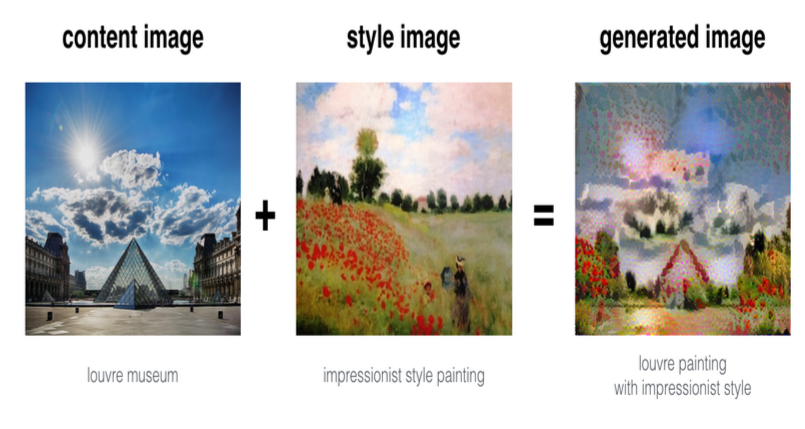

We didn't want have to wait too long to see an initial result, and so had set the hyperparameters accordingly. To get the best looking results, running the optimization algorithm longer (and perhaps with a smaller learning rate) might work better. We can come later and play with these to make even better results

Here are some egs:
* The beautiful ruins of the ancient city of Persepolis (Iran) with the style of Van Gogh (The Starry Night) ps -- My fav!!

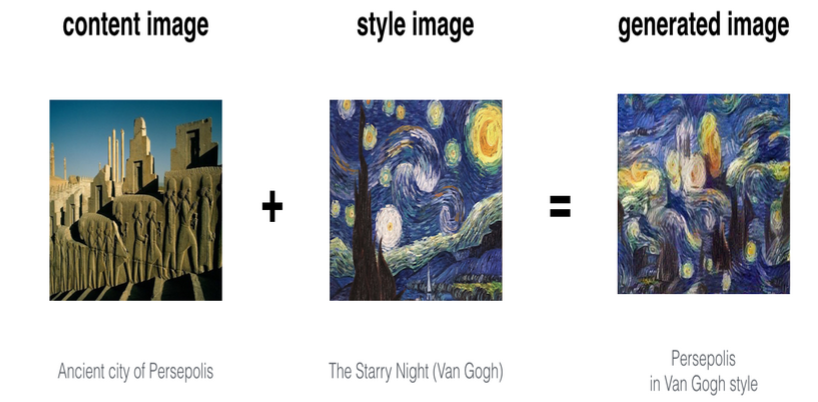

* The tomb of Cyrus the great in Pasargadae with the style of a Ceramic Kashi from Ispahan. 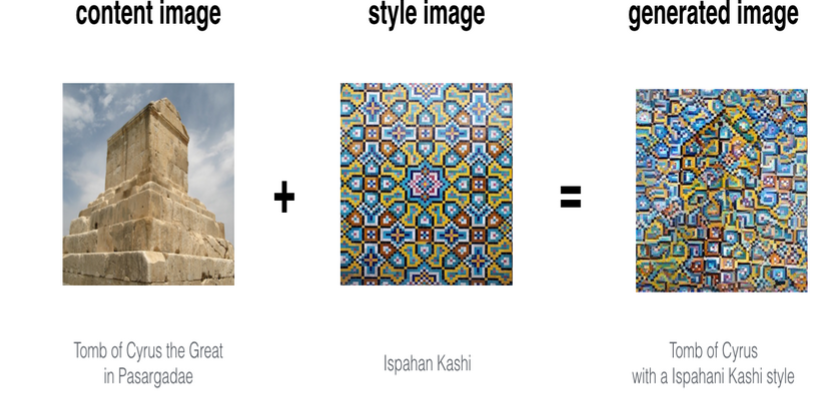

* The tomb of Cyrus the great in Pasargadae with the style of a Ceramic Kashi from Ispahan.

A scientific study of a turbulent fluid with the style of a abstract blue fluid painting. 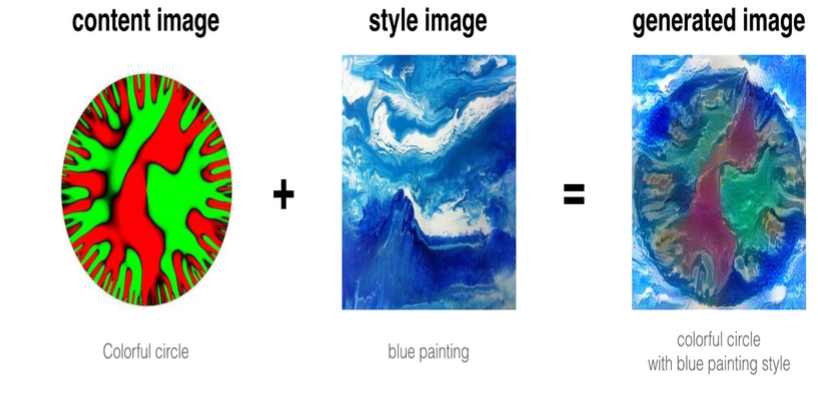

###Summary
 Neural Style Transfer is an algorithm that given a content image C and a style image S can generate an artistic image - It uses representations (hidden layer activations) based on a pretrained ConvNet. - The content cost function is computed using one hidden layer's activations. - The style cost function for one layer is computed using the Gram matrix of that layer's activations. The overall style cost function is obtained using several hidden layers. - Optimizing the total cost function results in synthesizing new images.